IMPORTING LIBRARIES

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IMPORTING DATASET

In [23]:
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

NORMALIZING THE DATA

In [24]:
x_train = x_train/255.0
x_test = x_test/255.0

FLATTENING THE IMAGES

In [25]:
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

BUILDING THE AUTOENCODER

In [26]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense

input_img = Input(shape=(784,))


#                                  ENCODER

encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)

#                                   DECODER

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)


autoencoder = Model(input_img, decoded)

COMPILE THE MODEL

In [27]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

TRAINING THE MODEL

In [28]:
autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.3439 - val_loss: 0.1605
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1496 - val_loss: 0.1231
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1199 - val_loss: 0.1086
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1086 - val_loss: 0.1024
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1026 - val_loss: 0.0985
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0992 - val_loss: 0.0957
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0964 - val_loss: 0.0931
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0937 - val_loss: 0.0913
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0919 - val_loss: 0.0918
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0904 - val_loss: 0.0882
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0890 - val_loss: 0.0876
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

RECONSTRUCT IMAGE

In [29]:
reconstructed_images = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


VISUALIZE THE RESULT

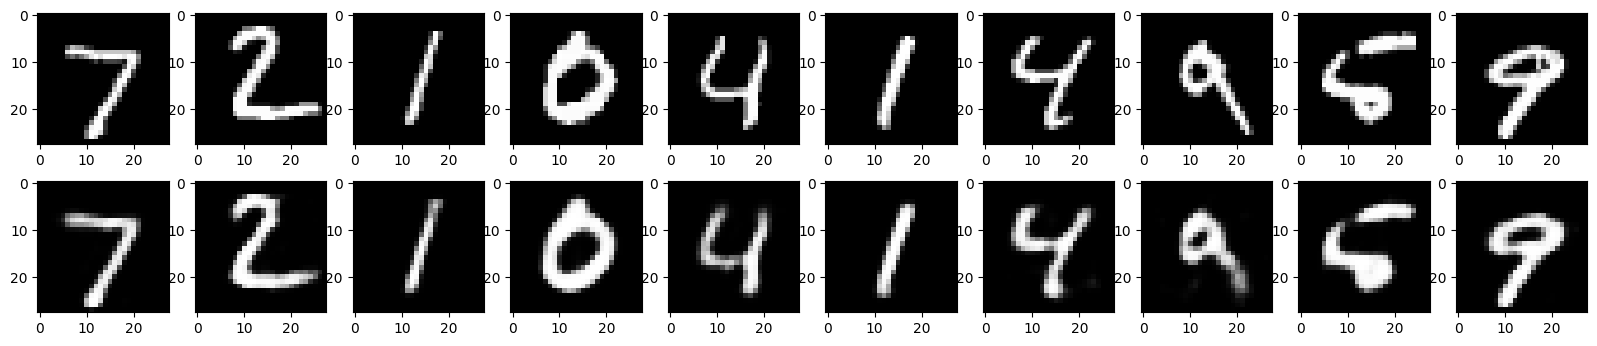

In [32]:
n = 10
plt.figure(figsize=(20,4))

for i in range(n):

#                                             original
    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()


#                                              reconstructed
    ax = plt.subplot(2,n,i+n+1)
    plt.imshow(reconstructed_images[i].reshape(28,28))
    plt.gray()

plt.show()